Scanning dataset folders...
Total WAV files found: 832
Missing files skipped: 461
Usable samples: 124
Extracting mel spectrograms...
Processed: 0 / 124
Processed: 50 / 124
Processed: 100 / 124
Loaded samples: 124
Dataset shape: (124, 128, 128, 1)


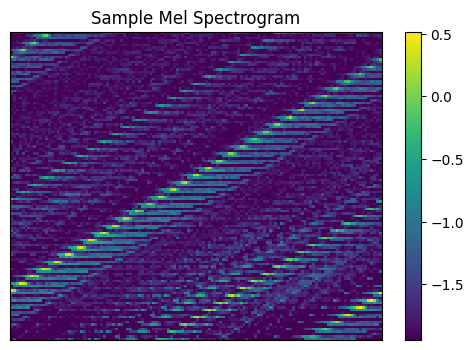

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 126, 126, 16)      160       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 63, 63, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 61, 61, 32)        4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 30, 30, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 28, 28, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 14, 14, 64)      

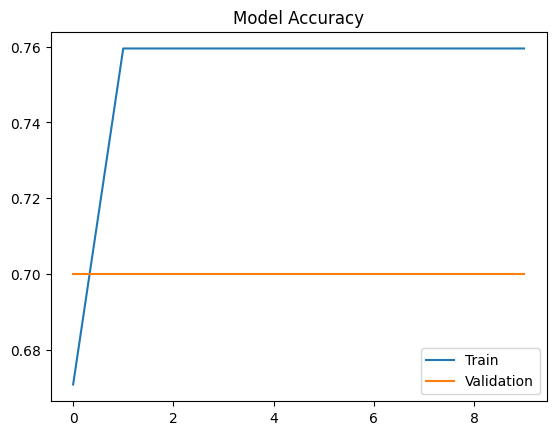

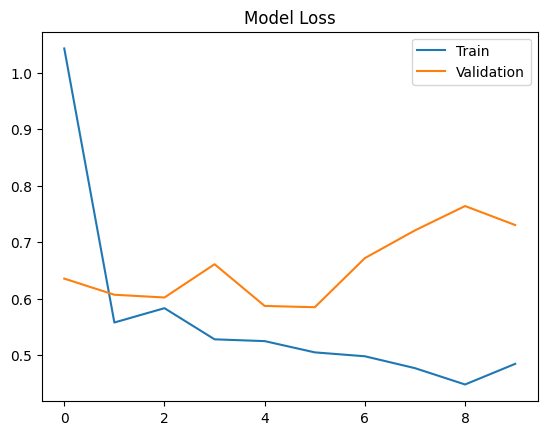

1/1 [==============================] - 0s 62ms/step
Accuracy: 0.76
F1 Score: 0.8636363636363636


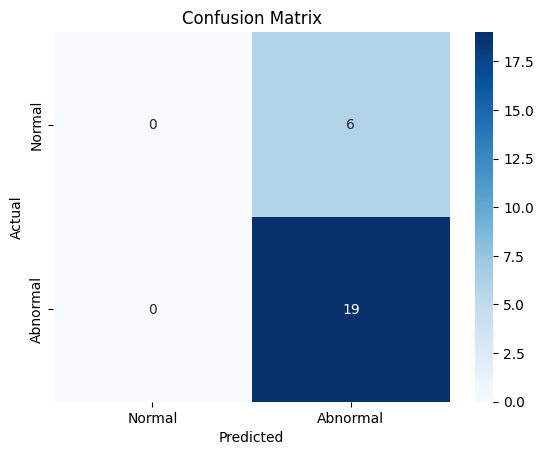

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.76      1.00      0.86        19

    accuracy                           0.76        25
   macro avg       0.38      0.50      0.43        25
weighted avg       0.58      0.76      0.66        25



c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

from tensorflow.keras import layers, models
import seaborn as sns


# -----------------------------
# PARAMETERS
# -----------------------------

DATA_ROOT = "data/heartbeat"
IMG_SIZE = (128,128)
SR = 22050


# -----------------------------
# LOAD CSV FILES
# -----------------------------

df_a = pd.read_csv(os.path.join(DATA_ROOT,"set_a.csv"))
df_b = pd.read_csv(os.path.join(DATA_ROOT,"set_b.csv"))

df = pd.concat([df_a,df_b], ignore_index=True)

df = df[df["label"].notna()]


# -----------------------------
# BINARY LABEL
# -----------------------------

df["binary_label"] = df["label"].apply(
    lambda x: 0 if x == "normal" else 1
)


# -----------------------------
# SCAN ACTUAL DATASET FILES
# -----------------------------

print("Scanning dataset folders...")

all_files = {}

for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith(".wav"):
            all_files[f] = os.path.join(root,f)

print("Total WAV files found:",len(all_files))


# -----------------------------
# BUILD PATHS SAFELY
# -----------------------------

paths = []
labels = []

missing = 0

for i,row in df.iterrows():

    fname = os.path.basename(row["fname"])

    if fname in all_files:

        paths.append(all_files[fname])
        labels.append(row["binary_label"])

    else:
        missing += 1


print("Missing files skipped:",missing)
print("Usable samples:",len(paths))


# -----------------------------
# AUDIO → MEL SPECTROGRAM
# -----------------------------

def audio_to_mel(path):

    signal, sr = librosa.load(path, sr=SR)

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=128,
        n_fft=1024,
        hop_length=512
    )

    mel = librosa.power_to_db(mel)

    mel = np.resize(mel, IMG_SIZE)

    return mel


# -----------------------------
# LOAD DATASET
# -----------------------------

data = []
y = []

print("Extracting mel spectrograms...")

for i,path in enumerate(paths):

    if i % 50 == 0:
        print("Processed:",i,"/",len(paths))

    mel_img = audio_to_mel(path)

    data.append(mel_img)
    y.append(labels[i])


X = np.array(data)
y = np.array(y)


print("Loaded samples:",len(X))


# -----------------------------
# NORMALIZE DATA
# -----------------------------

X = X.reshape(-1,128,128,1)

X = X / (np.max(X) + 1e-6)

print("Dataset shape:",X.shape)


# -----------------------------
# VISUALIZE SAMPLE
# -----------------------------

plt.figure(figsize=(6,4))

librosa.display.specshow(X[0].squeeze(), cmap="viridis")

plt.title("Sample Mel Spectrogram")

plt.colorbar()

plt.show()


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# -----------------------------
# CNN MODEL
# -----------------------------

model = models.Sequential([

    layers.Conv2D(16,(3,3),activation='relu',input_shape=(128,128,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(64,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1,activation='sigmoid')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# -----------------------------
# TRAIN MODEL
# -----------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


# -----------------------------
# ACCURACY PLOT
# -----------------------------

plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.legend(['Train','Validation'])

plt.show()


# -----------------------------
# LOSS PLOT
# -----------------------------

plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.legend(['Train','Validation'])

plt.show()


# -----------------------------
# MODEL EVALUATION
# -----------------------------

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))


# -----------------------------
# CONFUSION MATRIX
# -----------------------------

cm = confusion_matrix(y_test,y_pred)

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=["Normal","Abnormal"],
    yticklabels=["Normal","Abnormal"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# -----------------------------
# CLASSIFICATION REPORT
# -----------------------------

print(classification_report(y_test,y_pred))